# Day 08. Exercise 00
# Binary classifier. Logistic regression

## 0. Imports

In [25]:
import pandas as pd
import numpy as np
import datetime
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

## 1. Preprocessing

In [2]:
commits = pd.read_csv('../data/checker_timestamp.csv', parse_dates=['timestamp'])
commits.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


In [3]:
commits['date'] = commits.timestamp.dt.date
commits.head()

,timestamp,date
0,2020-04-17 05:19:02.744528,2020-04-17
1,2020-04-17 05:22:35.249331,2020-04-17
2,2020-04-17 05:22:45.549397,2020-04-17
3,2020-04-17 05:34:14.691200,2020-04-17
4,2020-04-17 05:34:24.422370,2020-04-17


In [4]:
commits['target'] = np.where(commits.timestamp.dt.day_name().isin(['Saturday', 'Sunday']),
                             'weekend',
                             'working_day')
commits.head()

,timestamp,date,target
0,2020-04-17 05:19:02.744528,2020-04-17,working_day
1,2020-04-17 05:22:35.249331,2020-04-17,working_day
2,2020-04-17 05:22:45.549397,2020-04-17,working_day
3,2020-04-17 05:34:14.691200,2020-04-17,working_day
4,2020-04-17 05:34:24.422370,2020-04-17,working_day


In [5]:
midday = datetime.time(hour=12)
commits['is_am'] = commits.timestamp.dt.time < midday
commits.head()

,timestamp,date,target,is_am
0,2020-04-17 05:19:02.744528,2020-04-17,working_day,True
1,2020-04-17 05:22:35.249331,2020-04-17,working_day,True
2,2020-04-17 05:22:45.549397,2020-04-17,working_day,True
3,2020-04-17 05:34:14.691200,2020-04-17,working_day,True
4,2020-04-17 05:34:24.422370,2020-04-17,working_day,True


In [6]:
df = commits.groupby(['date', 'target']).agg(
    am = pd.NamedAgg(column='is_am', aggfunc='sum'),
    pm = pd.NamedAgg(column='is_am', aggfunc=lambda x: x.count() - x.sum())
).reset_index()
df = df[['date', 'am', 'pm', 'target']]
df.head()

,date,am,pm,target
0,2020-04-17,21,2,working_day
1,2020-04-18,1,68,weekend
2,2020-04-19,18,15,weekend
3,2020-04-20,2,23,working_day
4,2020-04-21,0,25,working_day


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    35 non-null     object
 1   am      35 non-null     int64 
 2   pm      35 non-null     int64 
 3   target  35 non-null     object
dtypes: int64(2), object(2)
memory usage: 1.2+ KB


## 2. Exploratory analysis

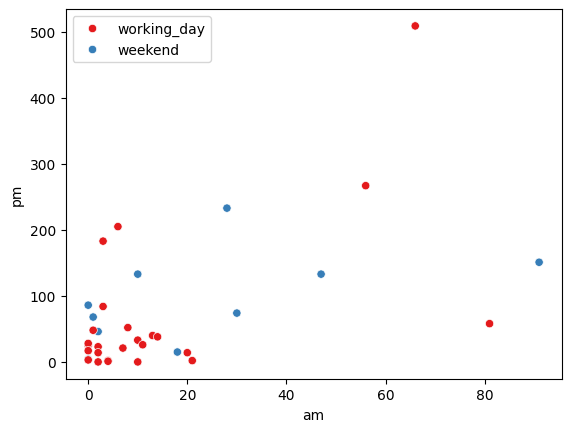

In [19]:
ax = sns.scatterplot(x='am', y='pm', hue='target', data=df, hue_order=['working_day', 'weekend'], palette='Set1')
ax.legend(loc='upper left')

*answer 1: no, it is not easy*

## 3. Logistic regression

In [29]:
X = df[['am', 'pm']]
y = df.target

In [30]:
lr = LogisticRegression(random_state=21, fit_intercept=False)

In [31]:
lr.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,False
,intercept_scaling,1
,class_weight,None
,random_state,21
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
y_pred = lr.predict(X)
df['predict'] = y_pred

In [14]:
df.to_csv('../data/am_pm.csv', index=False)

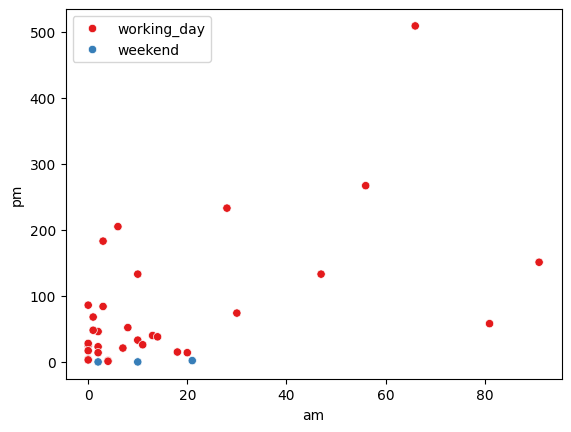

In [23]:
ax = sns.scatterplot(x='am', y='pm', hue='predict', data=df, hue_order=['working_day', 'weekend'], palette='Set1')
ax.legend(loc='upper left')

*answer 2: no*

## 4. Evaluation

In [33]:
acc = accuracy_score(y, y_pred)
acc

0.6285714285714286

In [34]:
accuracy_score(y, [df['target'].mode().values] * len(y))

0.7142857142857143

*answer 3: no, it is not good*